# What is concurrency?

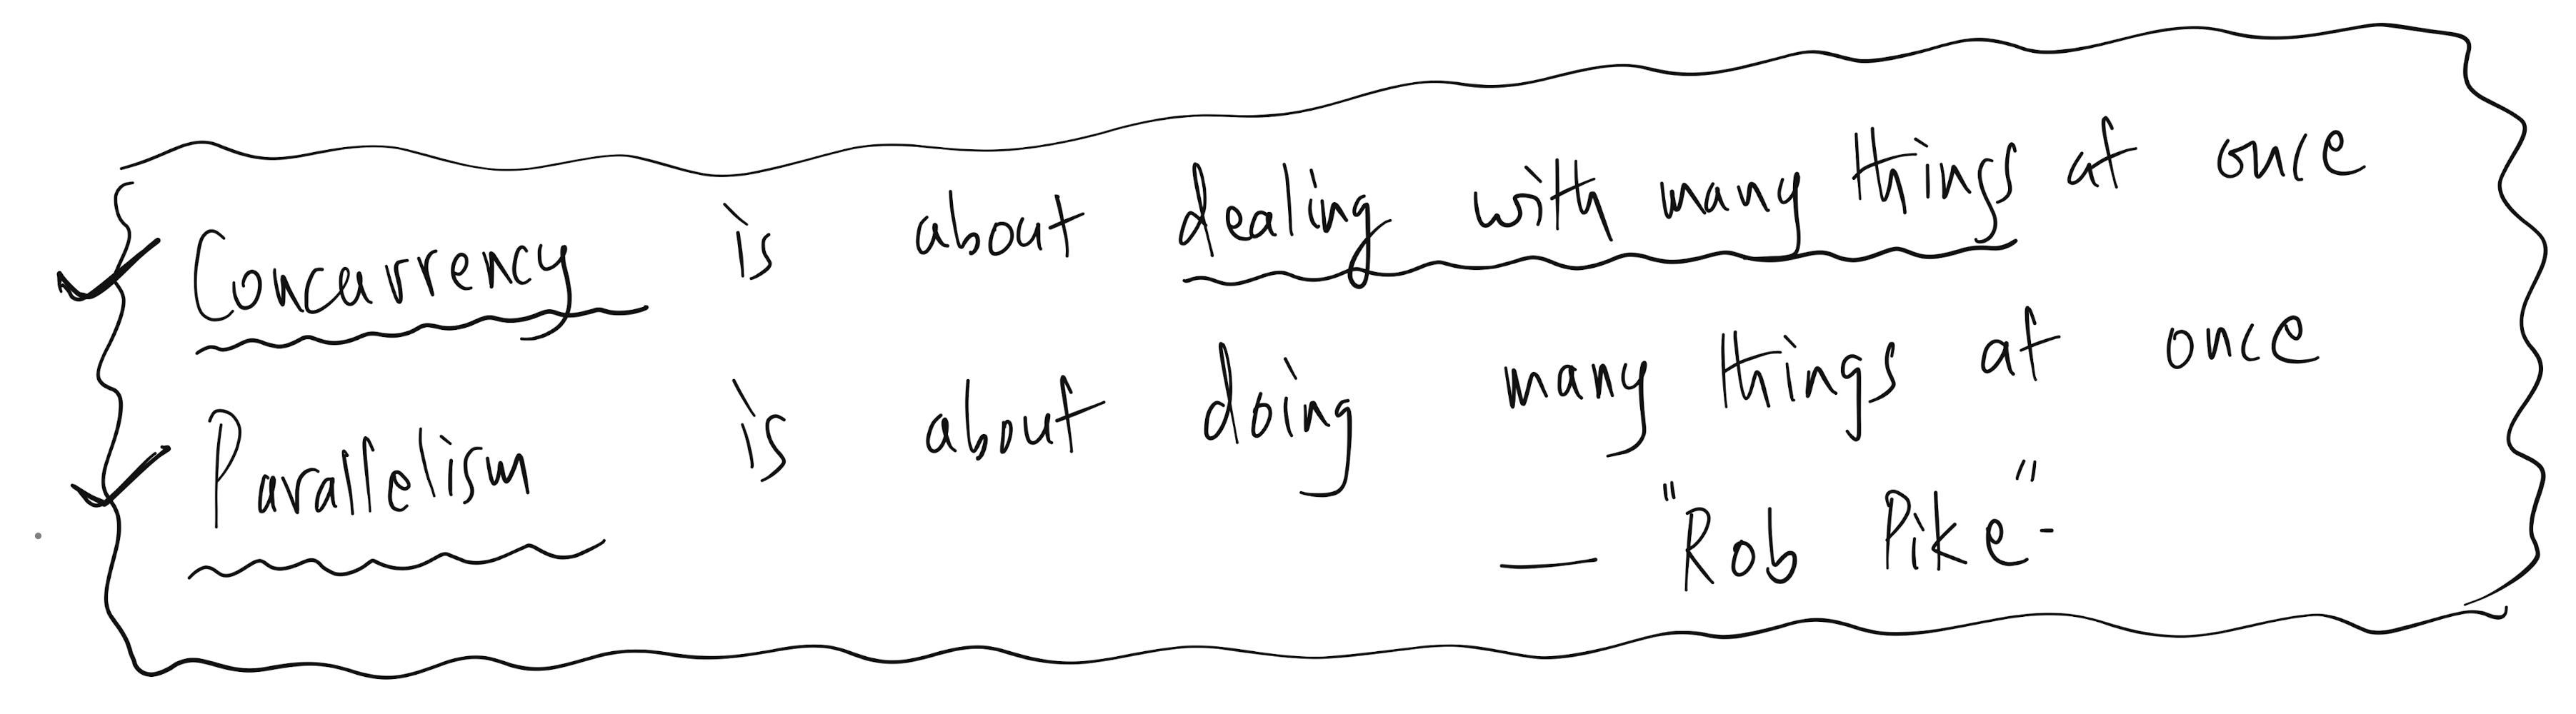



## 2 ways in which achieve concurrency in Python
    - Multithreading
    - Asynchronous programming

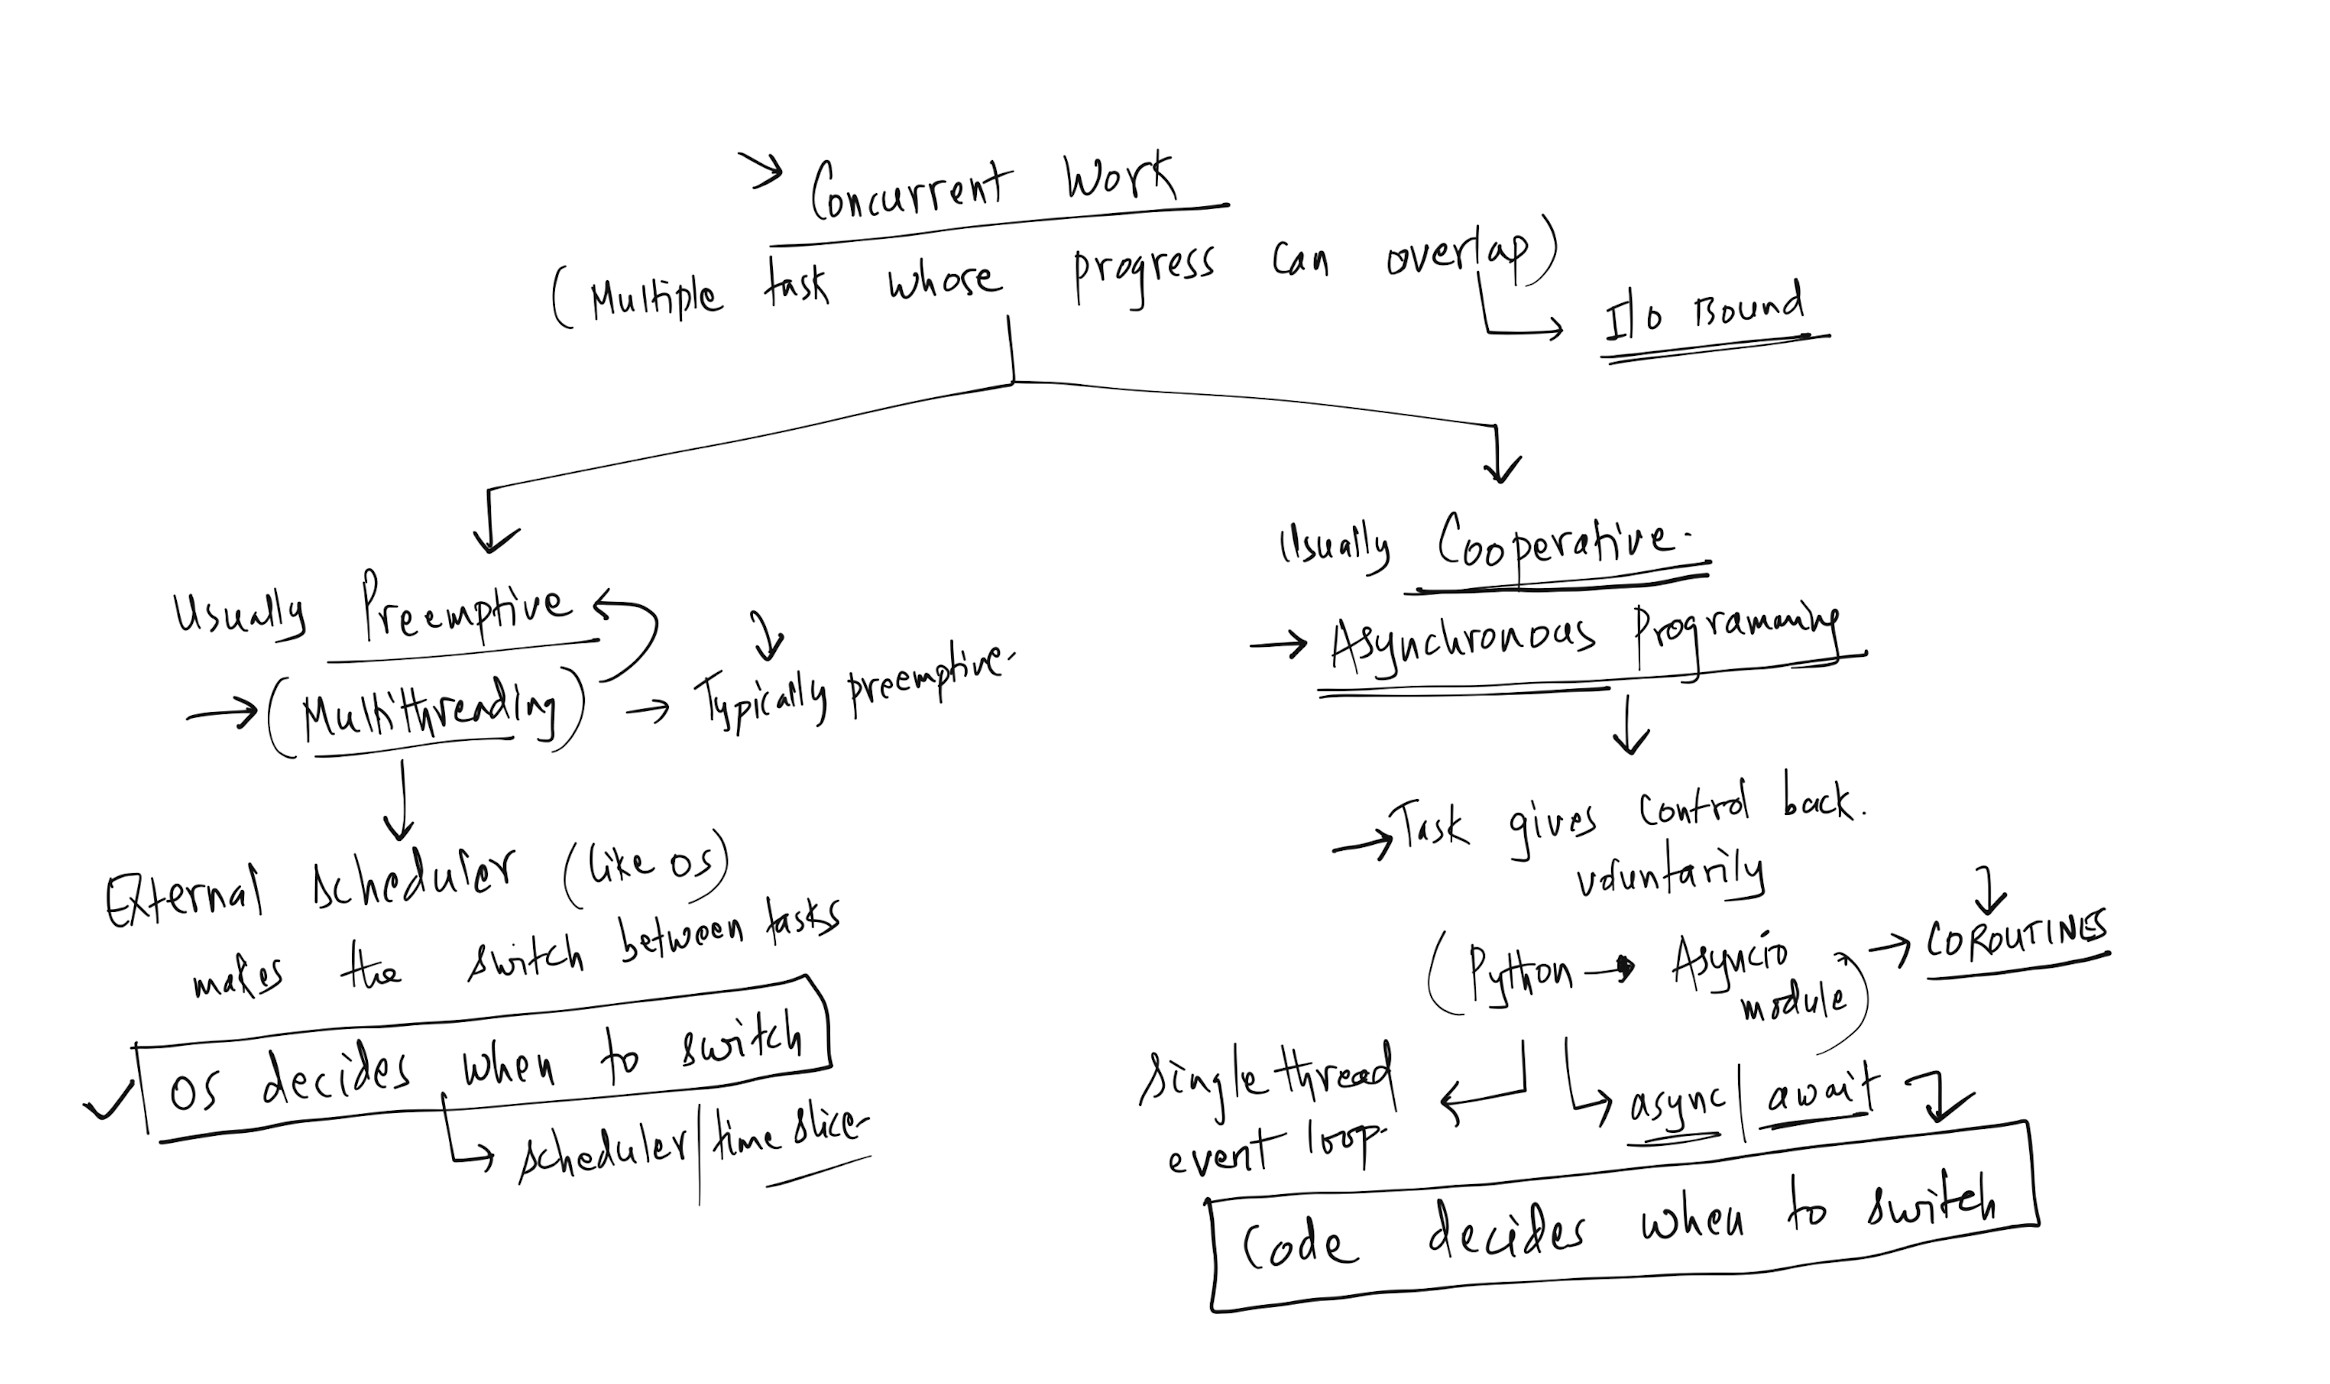

## Multithreading v/s Asynchronous Programming
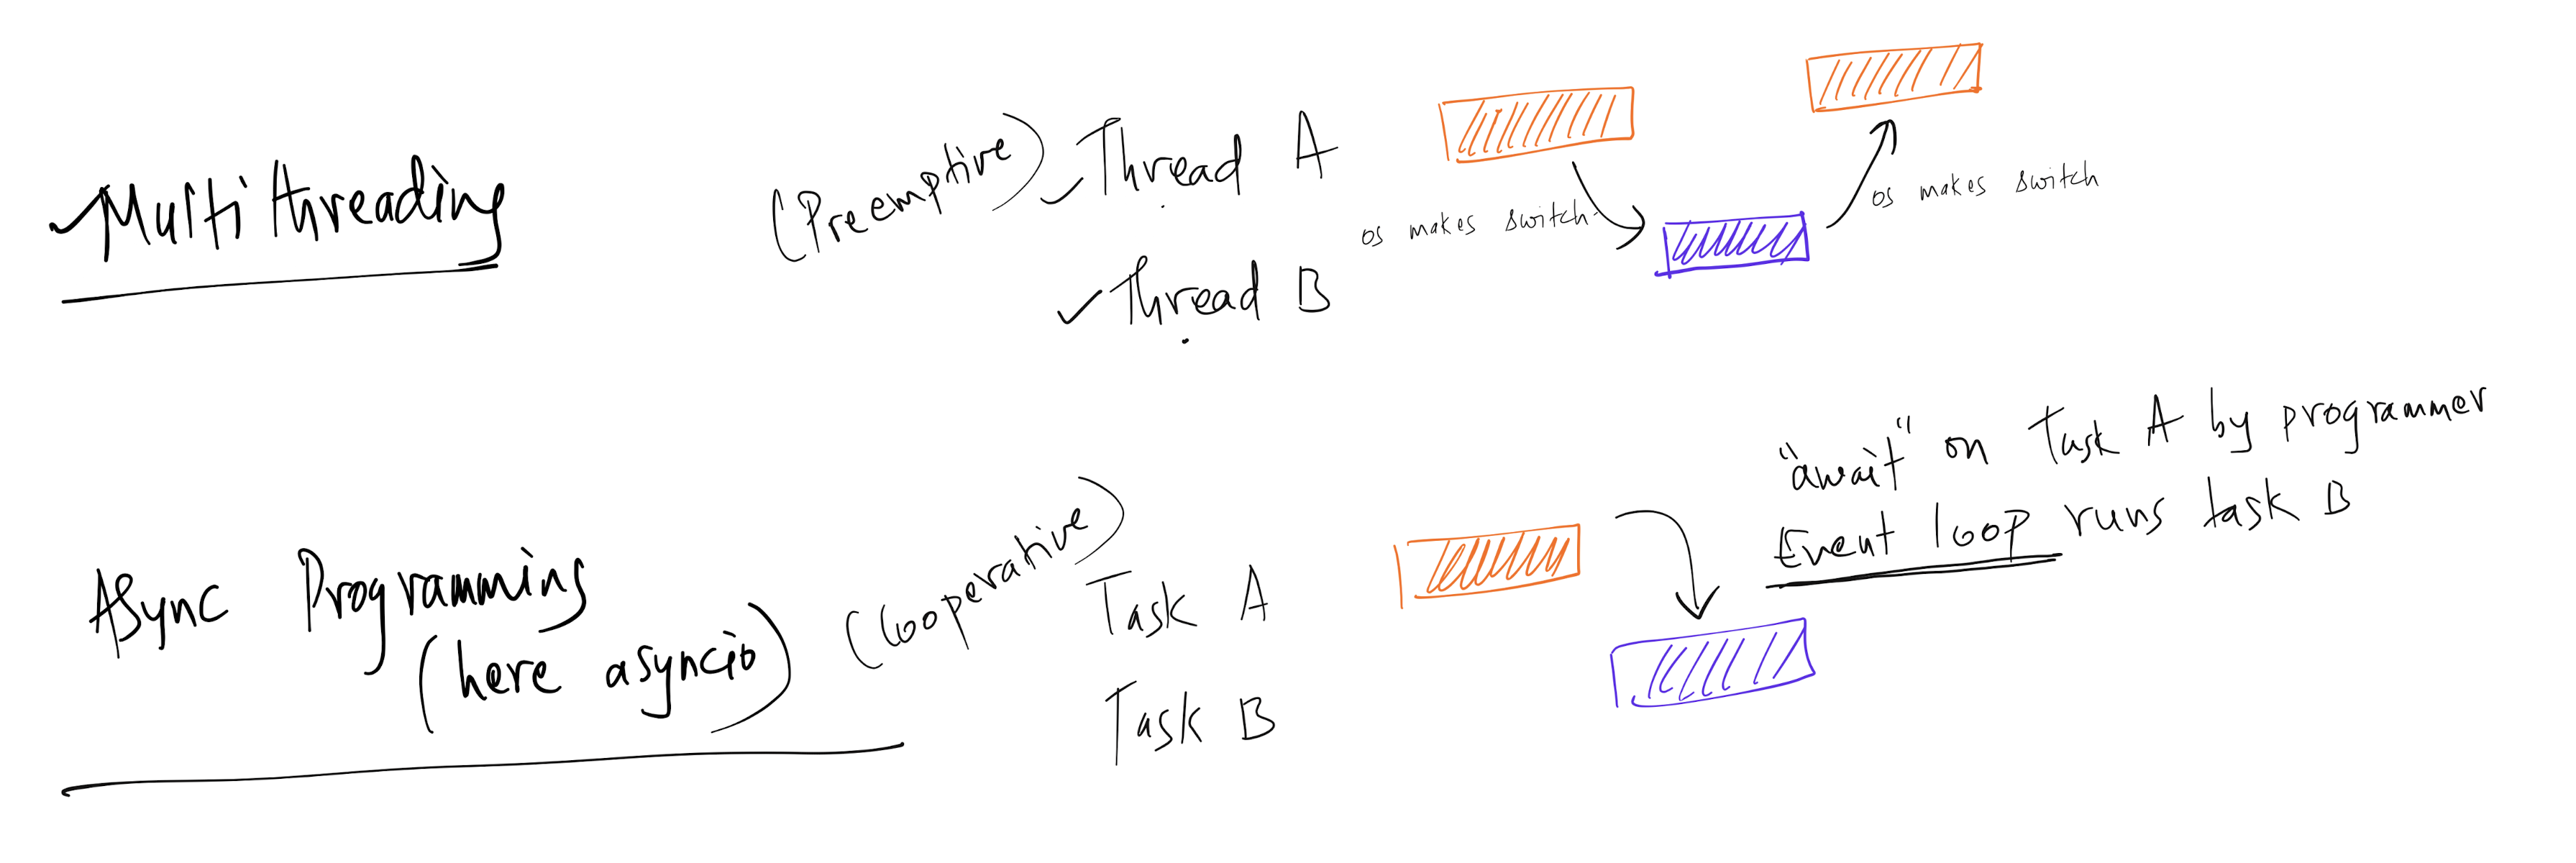


# Multithreading

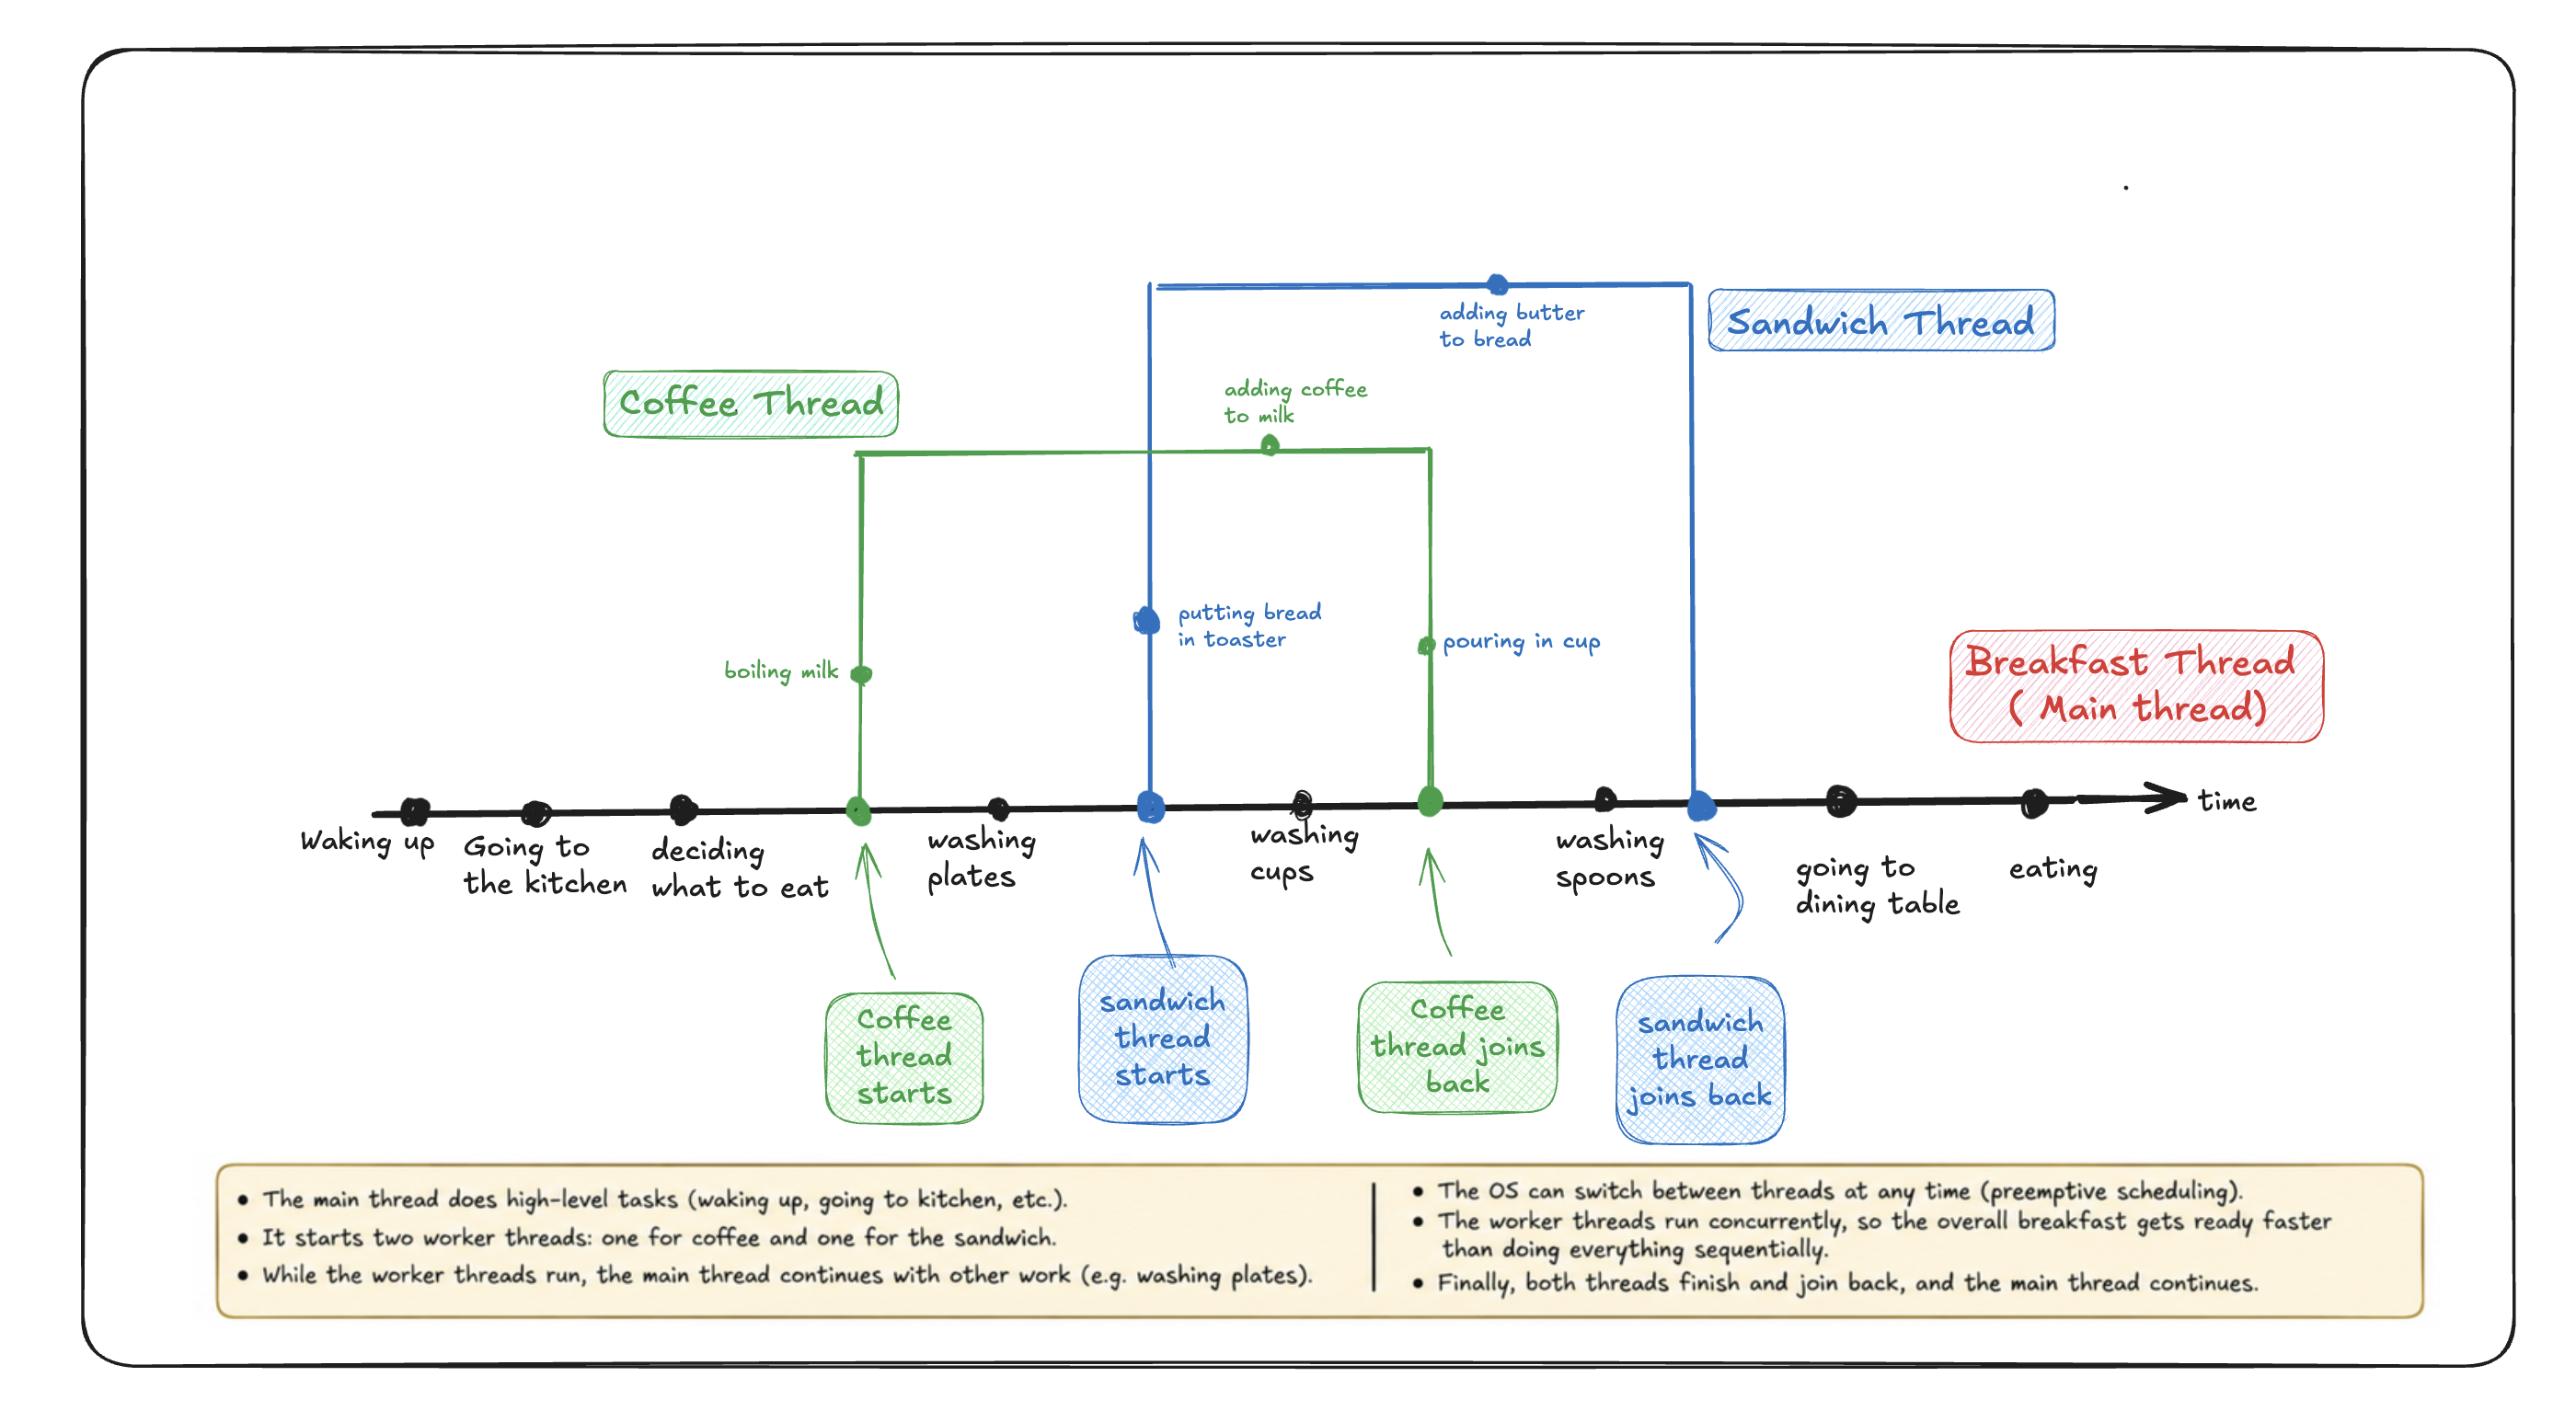

## Creating and observing the threads

In [9]:
import time
from datetime import datetime

def log(message):
    """
    Small helper so that every message shows:
    - current time
    - current thread name
    - what that thread is doing
    """

    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(
        f"{timestamp} | "
        f"{message}"
    )
    
    
def make_coffee():

    log("Boiling Water!!")
    time.sleep(5)

    log("Adding milk to coffee")
    time.sleep(1)

    log("Pouring to cup")
    time.sleep(2)

    log("Coffee is ready!!")


def make_sandwich():
    log("Started making sandwich")

    log("Putting bread in toaster")
    time.sleep(1)

    log("Waiting for toast")
    time.sleep(3)

    log("Adding butter to bread")
    time.sleep(1)

    log("Sandwich is ready")


start = time.time()

log("Waking up")
time.sleep(1)

log("Going to the kitchen")
time.sleep(1)

log("Deciding what to eat")
time.sleep(1)

make_coffee()

make_sandwich()

log("Washing plates")
time.sleep(1.5)


log("Washing cups")
time.sleep(1.5)

log("Washing spoons")
time.sleep(1.5)


log("Both coffee and sandwich are ready")

log("Going to dining table")
time.sleep(1)

log("Eating breakfast")

time_taken = time.time() - start

log(f"Total time taken: {time_taken}")

    

08:54:13.022 | Waking up
08:54:14.027 | Going to the kitchen
08:54:15.032 | Deciding what to eat
08:54:16.038 | Boiling Water!!
08:54:21.041 | Adding milk to coffee
08:54:22.047 | Pouring to cup
08:54:24.052 | Coffee is ready!!
08:54:24.053 | Started making sandwich
08:54:24.054 | Putting bread in toaster
08:54:25.057 | Waiting for toast
08:54:28.062 | Adding butter to bread
08:54:29.065 | Sandwich is ready
08:54:29.065 | Washing plates
08:54:30.578 | Washing cups
08:54:32.083 | Washing spoons
08:54:33.588 | Both coffee and sandwich are ready
08:54:33.588 | Going to dining table
08:54:34.594 | Eating breakfast
08:54:34.595 | Total time taken: 21.573307991027832


In [10]:
import threading

In [ ]:
# creating a thread 

coffee_thread = threading.Thread(target= make_coffee)
sandwich_thread = threading.Thread(target = make_sandwich)

# start a thread
coffee_thread.start()
sandwich_thread.start()

In [16]:
threading.active_count()

10

In [30]:
print(dir(threading.current_thread()))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_after_fork', '_args', '_bootstrap', '_bootstrap_inner', '_daemonic', '_delete', '_handle', '_ident', '_initialized', '_invoke_excepthook', '_kwargs', '_name', '_native_id', '_set_ident', '_set_native_id', '_started', '_stderr', '_target', 'daemon', 'getName', 'ident', 'isDaemon', 'is_alive', 'join', 'name', 'native_id', 'run', 'setDaemon', 'setName', 'start']


In [32]:
coffee_thread.is_alive()

False

In [23]:
import time
from datetime import datetime

def log(message):
    """
    Small helper so that every message shows:
    - current time
    - current thread name
    - what that thread is doing
    """
    current_thread = threading.current_thread()
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(
        f"\n{timestamp} | "
        f"{current_thread.name:<12} | "
        f"{message}"
        f"Active threads:{threading.active_count()}"
    )
    
    
def make_coffee():
    log("starting to make coffee now!!")
        
    log("Boiling Water!!")
    time.sleep(5)
    log("Boiling Water -->finished!!")

    log("Adding milk to coffee")
    time.sleep(1)
    log("Adding milk to coffee-->finished")

    log("Pouring to cup")
    time.sleep(2)
    log("Pouring to cup --> finished")

    log("Coffee is ready!!")


def make_sandwich():
    log("Started making sandwich now")

    log("Putting bread in toaster")
    time.sleep(1)
    log("Putting bread in toaster --> finished")

    log("Waiting for toast")
    time.sleep(3)

    log("Adding butter to bread")
    time.sleep(1)

    log("Sandwich is ready --> finished")


start = time.time()

log("Waking up")
time.sleep(1)

log("Going to the kitchen")
time.sleep(1)

log("Deciding what to eat")
time.sleep(1)

coffee_thread = threading.Thread(target= make_coffee, name = "coffee_thread")  # creating a thread
coffee_thread.start() # starting a thread

log("Washing plates")
time.sleep(1.5)

sandwich_thread = threading.Thread(target = make_sandwich, name = "sandwich_thread")
sandwich_thread.start()

log("Washing cups")
time.sleep(1.5)

log("Washing spoons")
time.sleep(1.5)

coffee_thread.join() ## will make the main thread wait for this to complete  --> # joining a thread
sandwich_thread.join() ## will make the main thread wait for this to complete


log("Both coffee and sandwich are ready")

log("Going to dining table")
time.sleep(1)

log("Eating breakfast")

time_taken = time.time() - start

log(f"Total time taken: {time_taken} ", )

    


09:53:51.996 | MainThread   | Waking upActive threads:10

09:53:53.008 | MainThread   | Going to the kitchenActive threads:10

09:53:54.028 | MainThread   | Deciding what to eatActive threads:10

09:53:55.038 | coffee_thread | starting to make coffee now!!Active threads:11

09:53:55.043 | coffee_thread | Boiling Water!!Active threads:11

09:53:55.044 | MainThread   | Washing platesActive threads:11

09:53:56.550 | sandwich_thread | Started making sandwich nowActive threads:12

09:53:56.552 | sandwich_thread | Putting bread in toasterActive threads:12

09:53:56.552 | MainThread   | Washing cupsActive threads:12

09:53:57.556 | sandwich_thread | Putting bread in toaster --> finishedActive threads:12

09:53:57.557 | sandwich_thread | Waiting for toastActive threads:12

09:53:58.059 | MainThread   | Washing spoonsActive threads:12

09:54:00.051 | coffee_thread | Boiling Water -->finished!!Active threads:12

09:54:00.053 | coffee_thread | Adding milk to coffeeActive threads:12

09:54:00.56

## Comparing sequential and threaded execution

In [36]:
import random

def send_email(name):
    print(f"sending email to : {name} ") 
    time.sleep(random.randint(1, 3)) 
    print(f"Email to {name} sent successfully!!") 
    
def send_sms(name): 
    print(f"sending sms to : {name} ") 
    time.sleep(random.randint(1,3)) 
    print(f"SMS delivered to {name} !!")

list_of_friends = ["Raju", "Shyam", "Babu Bhaiya"] 


start = time.time()

for friend in list_of_friends:
    send_email(friend)
    send_sms(friend)
time_taken = time.time() - start

print(f"Total time taken: {time_taken:.2f} seconds")

sending email to : Raju 
Email to Raju sent successfully!!
sending sms to : Raju 
SMS delivered to Raju !!
sending email to : Shyam 
Email to Shyam sent successfully!!
sending sms to : Shyam 
SMS delivered to Shyam !!
sending email to : Babu Bhaiya 
Email to Babu Bhaiya sent successfully!!
sending sms to : Babu Bhaiya 
SMS delivered to Babu Bhaiya !!
Total time taken: 11.05 seconds


In [39]:
import random

def log(message):
    """
    Small helper so that every message shows:
    - current time
    - current thread name
    - what that thread is doing
    """
    current_thread = threading.current_thread()
    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(
        f"\n{timestamp} | "
        f"{current_thread.name:<12} | "
        f"{message}"
        f"Active threads:{threading.active_count()}"
    )
    
def send_email(name):
    log(f"sending email to : {name} ") 
    time.sleep(random.randint(1, 3)) 
    log(f"Email to {name} sent successfully!!") 
    
def send_sms(name): 
    log(f"sending sms to : {name} ") 
    time.sleep(random.randint(1,3)) 
    log(f"SMS delivered to {name} !!")

list_of_friends = ["Raju", "Shyam", "Babu Bhaiya"] 

print(
    "Total threads before starting:",
    threading.active_count()
)

threads = []
for friend in list_of_friends:
    ## create the threads
    threads.append(threading.Thread(target=send_email, args=(friend, ), name = f"email_{friend}"))
    threads.append(threading.Thread(target=send_sms, args=(friend, ), name = f"sms_{friend}"))

print(
    "Total threads after creating:",
    threading.active_count()
)
  
## start the threads

for thread in threads:
    thread.start()

print(
    "Total threads after creating:",
    threading.active_count()
)


## join my threads
for thread in threads:
    thread.join()

log("All the email and sms are sent!!!")

print(
    "Total threads after finishing:",
    threading.active_count()
)


Total threads before starting: 10
Total threads after creating: 10

10:31:14.509 | email_Raju   | sending email to : Raju Active threads:11

10:31:14.510 | sms_Raju     | sending sms to : Raju Active threads:12

10:31:14.510 | email_Shyam  | sending email to : Shyam Active threads:13

10:31:14.510 | sms_Shyam    | sending sms to : Shyam Active threads:14

10:31:14.510 | email_Babu Bhaiya | sending email to : Babu Bhaiya Active threads:15

10:31:14.510 | sms_Babu Bhaiya | sending sms to : Babu Bhaiya Active threads:16
Total threads after creating: 16

10:31:16.515 | sms_Shyam    | SMS delivered to Shyam !!Active threads:16
10:31:16.517 | sms_Babu Bhaiya | SMS delivered to Babu Bhaiya !!Active threads:16


10:31:17.513 | sms_Raju     | SMS delivered to Raju !!Active threads:14
10:31:17.516 | email_Babu Bhaiya | Email to Babu Bhaiya sent successfully!!Active threads:14

10:31:17.516 | email_Shyam  | Email to Shyam sent successfully!!Active threads:13


10:31:17.516 | email_Raju   | Email 

## Seeing the threads better

In [43]:
threading.active_count()

10

In [42]:
threading.enumerate()

[<_MainThread(MainThread, started 8269492800)>,
 <Thread(IOPub, started daemon 6187675648)>,
 <Heartbeat(Heartbeat, started daemon 6204502016)>,
 <Thread(Thread-2 (_watch_pipe_fd), started daemon 6222475264)>,
 <Thread(Thread-3 (_watch_pipe_fd), started daemon 6239301632)>,
 <ControlThread(Control, started daemon 6256128000)>,
 <ShellChannelThread(Shell channel, started daemon 6272954368)>,
 <ParentPollerUnix(Thread-1, started daemon 6307180544)>,
 <HistorySavingThread(IPythonHistorySavingThread, started 6289780736)>,
 <GarbageCollectorThread(Thread-5, started daemon 6324006912)>]

In [46]:
import threading
import time
import os
from datetime import datetime


def show_threads(label):
    """
    Display what Python currently knows about its threads.
    """

    print(f"\n{'=' * 70}")
    print(label)
    print(f"{'=' * 70}")

    print(f"Process ID (PID): {os.getpid()}")
    print(f"Active thread count: {threading.active_count()}")

    for thread in threading.enumerate():
        print(
            f"  Thread name={thread.name!r}, "
            f"ident={thread.ident}, "
            f"native_id={thread.native_id}, "
            f"alive={thread.is_alive()}"
        )


def some_task():
    print(
        f"\nWorker executing: "
        f"name={threading.current_thread().name}, "
        f"ident={threading.current_thread().ident}, "
        f"native_id={threading.current_thread().native_id}"
    )

    time.sleep(10)


# STEP 1 - Inspect the process before creating our Thread object.

show_threads("---1. BEFORE creating Thread object---")

# STEP 2 - Create a Thread object (This does NOT start an OS thread yet)


coffee_worker = threading.Thread(
    target=some_task,
    name="CoffeeThread"
)

show_threads("2. AFTER creating Thread object")
print(
    "\nPython Thread object says:"
    f" name={coffee_worker.name!r},"
    f" ident={coffee_worker.ident},"
    f" native_id={coffee_worker.native_id},"
    f" alive={coffee_worker.is_alive()}"
)



# STEP 3 - Actually start the thread.

print("\nCalling worker.start()...")
coffee_worker.start()


show_threads("3. AFTER worker.start()")



# STEP 4 - Wait for the worker to finish.

coffee_worker.join()


show_threads("4. AFTER worker.join()")


---1. BEFORE creating Thread object---
Process ID (PID): 33935
Active thread count: 10
  Thread name='MainThread', ident=8269492800, native_id=16803677, alive=True
  Thread name='IOPub', ident=6187675648, native_id=16803693, alive=True
  Thread name='Heartbeat', ident=6204502016, native_id=16803694, alive=True
  Thread name='Thread-2 (_watch_pipe_fd)', ident=6222475264, native_id=16803697, alive=True
  Thread name='Thread-3 (_watch_pipe_fd)', ident=6239301632, native_id=16803698, alive=True
  Thread name='Control', ident=6256128000, native_id=16803699, alive=True
  Thread name='Shell channel', ident=6272954368, native_id=16803700, alive=True
  Thread name='Thread-1', ident=6307180544, native_id=16803723, alive=True
  Thread name='IPythonHistorySavingThread', ident=6289780736, native_id=17016563, alive=True
  Thread name='Thread-5', ident=6324006912, native_id=17016564, alive=True

2. AFTER creating Thread object
Process ID (PID): 33935
Active thread count: 10
  Thread name='MainThread

## Observing the thread lifecycle

In [50]:
import threading
import time
import os
from datetime import datetime


def log(message):
    """
    Print useful information about the current execution context.
    """

    now = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    current = threading.current_thread()
    print(
        f"{now} | "
        f"PID={os.getpid()} | "
        f"Thread={current.name} | "
        f"native_id={current.native_id} | "
        f"{message}"
    )


def worker():
    """
    Worker function executed by our thread.
    """

    log("Worker function STARTED")

    # Keep the thread alive for 10 seconds.
    # During this period the thread is alive, but sleeping.
    time.sleep(10)
    
    log("Worker function FINISHED")


# STEP 1: Create the Thread object

worker_thread = threading.Thread(
    target=worker,
    name="Worker-1"
)

print("\n--- AFTER CREATING THREAD OBJECT ---")

print("name      :", worker_thread.name)
print("ident     :", worker_thread.ident)
print("native_id :", worker_thread.native_id)
print("alive     :", worker_thread.is_alive())

# STEP 2: Start the thread

print("\n--- CALLING start() ---")

worker_thread.start()

print("\n--- IMMEDIATELY AFTER start() ---")

print("name      :", worker_thread.name)
print("ident     :", worker_thread.ident)
print("native_id :", worker_thread.native_id)
print("alive     :", worker_thread.is_alive())



# STEP 3: MainThread continues

print("\n--- MAIN THREAD CONTINUES ---")

for i in range(20):

    print(
        f"MainThread doing work {i + 1} | "
        f"Worker alive={worker_thread.is_alive()}"
    )

    time.sleep(2)



# STEP 4: Wait for the worker

print("\n--- MAIN THREAD CALLING join() ---")

worker_thread.join()

print("\n--- AFTER join() ---")

print("name      :", worker_thread.name)
print("ident     :", worker_thread.ident)
print("native_id :", worker_thread.native_id)
print("alive     :", worker_thread.is_alive())


--- AFTER CREATING THREAD OBJECT ---
name      : Worker-1
ident     : None
native_id : None
alive     : False

--- CALLING start() ---
11:07:24.270 | PID=33935 | Thread=Worker-1 | native_id=17683808 | Worker function STARTED

--- IMMEDIATELY AFTER start() ---
name      : Worker-1
ident     : 6341980160
native_id : 17683808
alive     : True

--- MAIN THREAD CONTINUES ---
MainThread doing work 1 | Worker alive=True
MainThread doing work 2 | Worker alive=True
MainThread doing work 3 | Worker alive=True
MainThread doing work 4 | Worker alive=True
MainThread doing work 5 | Worker alive=True
11:07:34.276 | PID=33935 | Thread=Worker-1 | native_id=17683808 | Worker function FINISHED
MainThread doing work 6 | Worker alive=False
MainThread doing work 7 | Worker alive=False
MainThread doing work 8 | Worker alive=False
MainThread doing work 9 | Worker alive=False
MainThread doing work 10 | Worker alive=False
MainThread doing work 11 | Worker alive=False
MainThread doing work 12 | Worker alive=Fal

## Race Conditions and deadlocks

### Shared memory in threads

In [51]:
import threading

shared_list = []

def append_items(tag):
    for i in range(3):
        shared_list.append(f"{tag}{i}")

t1 = threading.Thread(target=append_items, args=("A",))
t2 = threading.Thread(target=append_items, args=("B",))

t1.start()
t2.start()

t1.join()
t2.join()

print(shared_list)

['A0', 'A1', 'A2', 'B0', 'B1', 'B2']


### What is a race condition?
The central problem is very simple:

`Multiple threads can access the same piece of shared state, and the final result can depend on the timing and interleaving of their execution.`

That situation is called a race condition.

In [46]:
### simulate a race condition

import threading
import time
import random


counter = 0
iters = 20

def increment_many():
    global counter
    for _ in range(iters):
        current = counter
        # print("current = ",current)
        time.sleep(random.uniform(0.00001, 0.00005))
        counter = current + 1

num_threads = 4
threads = [threading.Thread(target=increment_many, name = "increment_thread") for _ in range(num_threads)]

print(f"{len(threads) = }")

for t in threads:
    t.start()

for t in threads: 
    t.join()

print("expected:", num_threads * iters)
print("actual  :", counter)


len(threads) = 4
expected: 80
actual  : 22


    Thread A       Thread B       Thread C
    
    read 0
                   read 0
                                  read 0
    
    write 1
                   write 1
                                  write 1


- three threads worked here but we ended up with counter = 1 instead of counter = 3
- Why is this called a "race"? - Because there is a competition between threads over the timing of operations.

In [48]:
import dis

def inc():
    global counter
    counter += 1

dis.dis(inc)

  3           RESUME                   0

  5           LOAD_GLOBAL              0 (counter)
              LOAD_CONST               1 (1)
              BINARY_OP               13 (+=)
              STORE_GLOBAL             0 (counter)
              RETURN_CONST             0 (None)


### critical sections and  threading.lock

#### critical section.

A critical section is a portion of code that accesses shared state and must be executed with the required synchronization so that multiple threads don't interfere with one another.

In our example, this is the dangerous sequence:

```
read counter
add 1
write counter
```

We want that entire operation to behave as one logical unit.

Conceptually:

                  Critical Section

              ┌──────────────────────┐
              │ read counter         │
              │ add 1                │
              │ write counter        │
              └──────────────────────┘
We dont want

```
Thread A enters
Thread A reads

Thread B enters
Thread B reads

Thread A writes
Thread B writes
```


We want

```
Thread A
   |
   v
[ read → increment → write ]
   |
   v
Thread B
   |
   v
[ read → increment → write ]
```

In [49]:
import threading, time

balance = 100

def withdraw(amount):
    global balance
    if balance >= amount:            # CHECK
        time.sleep(0.001)            # any pause at all: I/O, logging, GC, scheduler
        balance -= amount            # ACT
        print(f"withdrew {amount}, balance now {balance}")
    else:
        print(f"declined {amount}")

t1 = threading.Thread(target=withdraw, args=(100,))
t2 = threading.Thread(target=withdraw, args=(100,))
t1.start()
t2.start()
t1.join()
t2.join()

print("final balance:", balance)

withdrew 100, balance now 0
withdrew 100, balance now -100
final balance: -100


**Critical section** : a region of code that accesses shared state and must not be executed by more than one thread at a time.

**Mutual exclusion** : the guarantee that only one thread at a time is inside the critical section. ("Mutex" is short for this.)

#### threading.lock


#### What is a lock?

A lock is a synchronization mechanism that allows us to say:

"Only one thread at a time may enter this protected/critical section."

           ┌──────────────────┐
    T1 ───▶│   acquire()      │──▶ [ critical section ] ──▶ release() ──▶
           │                  │
    T2 ───▶│  ...blocked...   │╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌▶ acquire() ──▶ [ critical section ]
    T3 ───▶│  ...blocked...   │
           └──────────────────┘

In [63]:
### simulate a race condition

import threading
import time
import random


counter = 0
iters = 20

lock = threading.Lock()

def increment_many():
    global counter
    for _ in range(iters):
        with lock:
            ## this is the critical portion of the code
            current = counter
            # print("current = ",current)
            time.sleep(random.uniform(0.00001, 0.00005))
            counter = current + 1

num_threads = 4
threads = [threading.Thread(target=increment_many, name = "increment_thread") for _ in range(num_threads)]

print(f"{len(threads) = }")

for t in threads:
    t.start()

for t in threads: 
    t.join()

print("expected:", num_threads * iters)
print("actual  :", counter)


len(threads) = 4
expected: 80
actual  : 80


In [64]:
import threading, time


balance = 100

lock = threading.Lock()


def withdraw(amount):
    global balance
    with lock:
        if balance >= amount:            # CHECK
            time.sleep(0.001)            # any pause at all: I/O, logging, GC, scheduler
            balance -= amount            # ACT
            print(f"withdrew {amount}, balance now {balance}")
        else:
            print(f"declined {amount}")

t1 = threading.Thread(target=withdraw, args=(100,))
t2 = threading.Thread(target=withdraw, args=(100,))
t1.start()
t2.start()
t1.join()
t2.join()

print("final balance:", balance)

withdrew 100, balance now 0
declined 100
final balance: 0


The problem is not that the individual read or write necessarily failed. The problem is that the whole read-modify-write operation was not atomic.

We therefore want this:

    Thread A
    ┌─────────────────────┐
    │ read → modify → write│
    └─────────────────────┘
    
    Thread B
                           ┌─────────────────────┐
                           │ read → modify → write│
                           └─────────────────────┘

rather than allowing the operations to interleave.

    A useful way to think about atomicity is: Atomicity is about whether an operation can be observed or interfered with halfway through. A lock is one mechanism for providing that guarantee.
    
    There is another important distinction: atomicity and thread safety are not synonyms. Atomicity is a property of an individual operation or group of operations. Thread safety is the broader property that a component behaves correctly when accessed concurrently. We will see later that achieving thread safety may require more than simply putting a lock around one statement.

#### acquire and release of locks

For example:

```python
import threading


lock = threading.Lock()
lock.acquire()

try:
    print("Thread entered critical section")

    # Shared state modification happens here.

finally:
    lock.release()

print("Thread left critical section")
```

    Thread A
       |
       | acquire()
       v
    ┌───────────────────┐
    │   LOCKED          │
    │                   │
    │ critical section  │
    │                   │
    └─────────┬─────────┘
              |
              | release()
              v
           UNLOCKED

What happens when thread A and thread B both try to access critical section    
    
    Thread A                    Thread B
        
        acquire()
            |
            v
         LOCKED
            |
         critical section       acquire()
                                    |
                                    v
                                 WAITING
                                    |
                                    |
         release()                  |
            |                       |
            └──────────────────────>|
                                    |
                               acquires lock
                                    |
                                    v
                             critical section

The important difference is that with is the safer and more convenient way to express the pattern because Python guarantees that the lock is released when the block is exited, including when an exception occurs.

These are conceptually equivalent:

```python
lock.acquire()

try:
    # Critical section
    update_shared_state()

finally:
    lock.release()
```

and:

```python
with lock:
    # Critical section
    update_shared_state()
```

The second form is essentially using the lock as a context manager. Under the hood, Python calls acquire() when entering the with block and release() when leaving it.

So why would we ever use acquire() directly?

Because acquire() gives you more control over the locking behavior.

For example, you can ask Python not to wait if the lock is currently unavailable:

```python
acquired = lock.acquire(blocking=False)

if acquired:
    try:
        # We successfully acquired the lock.
        update_shared_state()
    finally:
        lock.release()
else:
    # Someone else currently owns the lock.
    print("Could not acquire lock; doing something else.")
```

Here, ```with lock```: cannot directly express the same "try once and don't wait" behavior.

You can also specify a timeout:

```python
acquired = lock.acquire(timeout=2)

if acquired:
    try:
        update_shared_state()
    finally:
        lock.release()
else:
    print("Lock was not acquired within 2 seconds.")
```

So the practical rule is:

```
with lock:
    ...
```
    
is the normal choice when you simply want to protect a critical section.
```
lock.acquire(...)
lock.release()
```

is useful when you need explicit control over acquisition, such as non-blocking acquisition, timeouts, or more complicated synchronization logic.

One subtle but important point: never casually write this:

```python
lock.acquire()

update_shared_state()

lock.release()
```
    
because if update_shared_state() raises an exception, release() may never execute, leaving the lock permanently acquired. That can cause other threads to wait forever. If you need manual acquire()/release(), use try/finally.

In [70]:
import threading, time


balance = 100

lock = threading.Lock()


def withdraw(amount):
    global balance
    lock.acquire()

    try:
        if balance >= amount:            # CHECK
            time.sleep(0.001)            # any pause at all: I/O, logging, GC, scheduler
            balance -= amount            # ACT
            print(f"withdrew {amount}, balance now {balance}")
        else:
            print(f"declined {amount}")

    finally:
        lock.release()

t1 = threading.Thread(target=withdraw, args=(100,))
t2 = threading.Thread(target=withdraw, args=(100,))
t1.start()
t2.start()
t1.join()
t2.join()

print("final balance:", balance)

withdrew 100, balance now 0
declined 100
final balance: 0


So when would you use manual acquire() / release()?

    with lock: should normally be your default choice when the entire critical section can simply be protected by one lock.

    Manual acquire() becomes useful when you need more control, for example:

```python
if lock.acquire(timeout=1): # If the lock is unavailable, wait until it becomes available.
    try:
        # critical section
        ...
    finally:
        lock.release()
else:
    print("Could not acquire lock")
```

another example:

```python
if lock.acquire(blocking=False): #Try to acquire the lock, but don't wait.
    try:
        # critical section
        ...
    finally:
        lock.release()
else:
    print("Lock is currently busy")
```

So why would we ever use acquire() directly?

Because acquire() gives you more control over the locking behavior.

For example, you can ask Python not to wait if the lock is currently unavailable:

```python
acquired = lock.acquire(blocking=False)

if acquired:
    try:
        # We successfully acquired the lock.
        update_shared_state()
    finally:
        lock.release()
else:
    # Someone else currently owns the lock.
    print("Could not acquire lock; doing something else.")
```

Here, ```with lock```: cannot directly express the same "try once and don't wait" behavior.

You can also specify a timeout:

```python
acquired = lock.acquire(timeout=2)

if acquired:
    try:
        update_shared_state()
    finally:
        lock.release()
else:
    print("Lock was not acquired within 2 seconds.")
```

So the practical rule is:

```
with lock:
    ...
```
    
is the normal choice when you simply want to protect a critical section.
```
lock.acquire(...)
lock.release()
```

is useful when you need explicit control over acquisition, such as non-blocking acquisition, timeouts, or more complicated synchronization logic.

In [71]:
# Two threads competing for one lock

import threading
import time
from datetime import datetime


lock = threading.Lock()


def log(message):
    """
    Print the current time and thread name so that we can
    observe the ordering of events.
    """

    timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    thread = threading.current_thread()

    print(
        f"{timestamp} | "
        f"{thread.name:<12} | "
        f"{message}"
    )


def worker():
    log("About to call lock.acquire()")

    # This thread will wait here if another thread already
    # owns the lock.
    lock.acquire()

    try:
        log("Successfully acquired the lock")

        # Hold the lock for 5 seconds.
        log("Entering critical section")
        time.sleep(5)
        log("Leaving critical section")

    finally:
        # Always release the lock.
        lock.release()

        log("Released the lock")


thread_a = threading.Thread(target=worker,name="Worker-A")
thread_b = threading.Thread(target=worker,name="Worker-B")


log("Starting Worker-A")
thread_a.start()

# Give Worker-A enough time to acquire the lock before starting Worker-B.
time.sleep(0.5)

log("Starting Worker-B")
thread_b.start()

thread_a.join()
thread_b.join()

log("Both workers finished")

20:48:25.704 | MainThread   | Starting Worker-A
20:48:25.708 | Worker-A     | About to call lock.acquire()
20:48:25.708 | Worker-A     | Successfully acquired the lock
20:48:25.708 | Worker-A     | Entering critical section
20:48:26.218 | MainThread   | Starting Worker-B
20:48:26.219 | Worker-B     | About to call lock.acquire()
20:48:30.713 | Worker-A     | Leaving critical section
20:48:30.716 | Worker-A     | Released the lock
20:48:30.716 | Worker-B     | Successfully acquired the lock
20:48:30.716 | Worker-B     | Entering critical section
20:48:35.719 | Worker-B     | Leaving critical section
20:48:35.721 | Worker-B     | Released the lock
20:48:35.721 | MainThread   | Both workers finished


what happened in the above code:


    Worker-A:
        acquired lock
        entered critical section
        ...
        ...
        released lock
    
    Worker-B:
        called acquire()
        WAITED
        WAITED
        WAITED
        lock became available
        acquired lock
        entered critical section


This is **lock contention**. Multiple threads want the same resource, but the resource can only be accessed by one thread at a time.

#### acquire can be non-blocking

In [73]:
import threading
import time


lock = threading.Lock()


def worker_a():
    with lock:
        print("Worker-A acquired the lock")
        time.sleep(5)
        print("Worker-A releasing the lock")


def worker_b():
    time.sleep(1)

    print("Worker-B trying to acquire the lock")

    acquired = lock.acquire(blocking=False)

    if acquired:
        try:
            print("Worker-B acquired the lock")
        finally:
            lock.release()
    else:
        print("Worker-B could not acquire the lock")
        print("Worker-B will do something else")


thread_a = threading.Thread(
    target=worker_a,
    name="Worker-A"
)

thread_b = threading.Thread(
    target=worker_b,
    name="Worker-B"
)

thread_a.start()
thread_b.start()

thread_a.join()
thread_b.join()

Worker-A acquired the lock
Worker-B trying to acquire the lock
Worker-B could not acquire the lock
Worker-B will do something else
Worker-A releasing the lock


Here Worker-B doesn't wait for Worker-A.

Instead:

    Worker-A:
        acquire
        |
        | holds lock for 5 sec
        |
        release
    
    
    Worker-B:
        acquire(blocking=False)
              |
              v
          unavailable
              |
              v
          immediately continue

This is useful when waiting is undesirable and the application has an alternative course of action.

In [74]:
import threading
import time


lock = threading.Lock()


def worker_a():
    with lock:
        print("Worker-A acquired the lock")

        time.sleep(5)

        print("Worker-A releasing the lock")


def worker_b():
    time.sleep(1)

    print("Worker-B trying to acquire the lock")

    acquired = lock.acquire(timeout=2)

    if acquired:
        try:
            
            print("Worker-B acquired the lock")
        finally:
            lock.release()
    else:
        print("Worker-B timed out waiting for the lock")


thread_a = threading.Thread(target=worker_a)
thread_b = threading.Thread(target=worker_b)

thread_a.start()
thread_b.start()

thread_a.join()
thread_b.join()

Worker-A acquired the lock
Worker-B trying to acquire the lock
Worker-B timed out waiting for the lock
Worker-A releasing the lock


#### Check-Then-Act

The check-then-act pattern is one of the most important concurrency patterns to understand because many real-world operations naturally have two steps: first we check whether some condition is true, and then we perform an action based on that observation. The problem is that, when multiple threads are involved, another thread can change the shared state between the check and the action.

Example:
```python
if self.stock > 0:
    self.stock -= 1
```

It looks like one logical operation to us, but it actually contains two distinct operations:

    CHECK                         ACT
    
    Is stock > 0?                 Decrease stock
         │                             │
         └──────────── time ───────────┘

    That gap between the check and the action is where another thread can interfere.


Imagine a cinema with one available seat.

```python
class Seat:
    def __init__(self):
        self.available = True

    def book(self):
        if self.available:       # CHECK
            self.available = False  # ACT
            return True

        return False
```
In a sequential program, this appears perfectly safe. If Customer A books the seat first, available becomes False, and Customer B subsequently sees False. But concurrency changes the situation.


Suppose Customer A and Customer B are represented by two threads:

        Initial state:
        
        available = True
        
        
        Thread A                         Thread B
        
        CHECK
        available == True
                                         CHECK
                                         available == True
        
        ACT
        available = False
                                         ACT
                                         available = False

Both customers observed the seat as available. The problem is that the condition was checked before either thread performed the action. Both threads effectively received permission to book the same resource. This is a race condition caused by a check-then-act sequence.


Correct version:

```python
import threading


class Seat:
    def __init__(self):
        self.available = True
        self.lock = threading.Lock()

    def book(self):
        with self.lock:
            # CHECK and ACT are inside the same critical section.
            if self.available:
                self.available = False
                return True

            return False
```


Now the execution is:

        Thread A                         Thread B
        
        acquire lock
            |
            v
        CHECK
        available == True
            |
            v
        ACT
        available = False
            |
            v
        release lock
                                         acquire lock
                                             |
                                             v
                                         CHECK
                                         available == False
                                             |
                                             v
                                         return False


 The second thread cannot perform its check until the first thread has completed its action.

This gives us the crucial property:
```The state observed during the check cannot be changed by another thread before the corresponding action is performed.```
That is the real reason we put the check and act inside the same critical section.

## Check-then-act isn't always obvious

The pattern can be hidden inside apparently innocent code.

For example:
```python
if key not in cache:
    cache[key] = expensive_calculation()

```

This is also check-then-act.

The check is:

```python
key not in cache
```
    
and the action is:
```python
cache[key] = ...
```

Two threads could do:

    Thread A                         Thread B
    
    check key not in cache
    → True
    
                                     check key not in cache
                                     → True
    
    calculate value
                                     calculate value
    
    store value
                                     store value

Whether this is actually a correctness problem depends on what the application requires. Perhaps calculating the value twice is merely inefficient; perhaps the calculation has side effects and doing it twice is incorrect.

This is an important concurrency lesson:


When you see code like this:

```python
if condition:
    modify_shared_state()
```

you should immediately ask:

```Can another thread modify the state between my check and my action?```

If yes, you potentially have a check-then-act race.

```Does the correctness of the action depend on the condition remaining true?```

If yes, the check and action generally need to be protected together.

For example:

```Inventory:```

    check stock > 0
           ↓
    decrement stock

```Bank account```:

    check balance >= amount
           ↓
    deduct amount

```Seat Booking:```

    check available
           ↓
    mark booked
        
```Parking:```

    check capacity available
           ↓
    increment occupancy

These are all similar concurrency patterns that we come accross very often. 

To summarise:


          Shared State
               |
               v
            CHECK
               |
               |  <-- dangerous window
               |
               v
             ACT

If another thread can modify the relevant state during that window, you have a potential race.


Using a lock correctly turns it into:

                 acquire lock
                  |
                  v
                CHECK
                  |
                  v
                 ACT
                  |
                  v
             release lock

#### Another example of no so obvious race condition - Cache Population

Suppose we have an expensive function:

```python
def fetch_from_database(user_id):
    print(f"Fetching user {user_id} from database...")
    time.sleep(2)
    return f"User-{user_id}"

```

We want to cache the result.

A naive cache implementation might be:

```python
class UserCache:

    def __init__(self):
        self.cache = {}

    def get_user(self, user_id):

        # CHECK
        if user_id in self.cache:
            print("Cache HIT")
            return self.cache[user_id]

        # ACT
        print("Cache MISS")

        user = fetch_from_database(user_id)

        self.cache[user_id] = user

        return user
```
At first glance, this looks fine.

Suppose Ramesh and Suresh both request` get_user(42)` at almost exactly the same time.

    The execution could be:
    
    Ramesh                         Suresh
    -----                         ---
    
    check cache
    42 not present
    
                                  check cache
                                  42 not present
    
    fetch database               fetch database
    
                                  fetch database
    
    store result                 store result

The cache is still correct. We didn't corrupt the dictionary. 
But we have a concurrency bug of a different kind.

Instead of 1 database request we made 2 database requests

If 1,000 requests arrive simultaneously for a cache-missing key, we could potentially generate 1,000 database requests for the same data.

This is sometimes called a `cache stampede` / `thundering herd problem`. And this is why race conditions are interesting: the program doesn't necessarily crash or produce obviously incorrect data.

It can simply become inefficient or overload another system.

##### No lock: duplicate database work

        Ramesh                         Suresh
          |                              |
          | cache check                  |
          | → MISS                       |
          |                              |
          |                         cache check
          |                         → MISS
          |                              |
          | DB call                      | DB call
          |                              |
          +---------- 2 seconds ---------+

In [76]:
import threading
import time


def fetch_from_database(user_id):
    print(f"DB: fetching user {user_id}")
    time.sleep(2)
    return f"User-{user_id}"


class UserCache:

    def __init__(self):
        self.cache = {}

    def get_user(self, user_id):

        print(f"{threading.current_thread().name}: checking cache")

        # CHECK
        if user_id in self.cache:
            print(f"{threading.current_thread().name}: CACHE HIT")
            return self.cache[user_id]

        print(f"{threading.current_thread().name}: CACHE MISS")

        # ACT
        user = fetch_from_database(user_id)

        self.cache[user_id] = user

        return user


cache = UserCache()

barrier = threading.Barrier(2)


def get_user(customer):

    print(f"{customer}: starting")

    # Both threads reach the same point
    barrier.wait()

    user = cache.get_user(42)

    print(f"{customer}: received {user}")

ramesh = threading.Thread(target=get_user,args=("Ramesh",),name="rameshThread")
suresh = threading.Thread(target=get_user,args=("Suresh",),name="sureshThread")

ramesh.start()
suresh.start()

ramesh.join()
suresh.join()

Ramesh: starting
Suresh: starting
sureshThread: checking cache
sureshThread: CACHE MISS
DB: fetching user 42
rameshThread: checking cache
rameshThread: CACHE MISS
DB: fetching user 42
Ramesh: received User-42Suresh: received User-42



Both threads see the cache as empty and both perform the expensive database operation.
The cache itself is not necessarily corrupted. The final value may be perfectly correct.
The problem is that we performed work twice when we wanted it performed once.

In [77]:
# Now we add a lock around the check + database fetch + cache update
import threading
import time


def fetch_from_database(user_id):
    print(f"DB: fetching user {user_id}")
    time.sleep(2)
    return f"User-{user_id}"


class UserCache:

    def __init__(self):
        self.cache = {}
        self.lock = threading.Lock()

    def get_user(self, user_id):

        with self.lock:

            print(f"{threading.current_thread().name}: checking cache")

            # CHECK
            if user_id in self.cache:
                print(f"{threading.current_thread().name}: CACHE HIT")
                return self.cache[user_id]

            print(f"{threading.current_thread().name}: CACHE MISS")

            # ACT
            user = fetch_from_database(user_id)

            self.cache[user_id] = user

            return user


cache = UserCache()

def get_user(customer):

    print(f"{customer}: starting")
    user = cache.get_user(42)
    print(f"{customer}: received {user}")


ramesh = threading.Thread(target=get_user,args=("Ramesh",),name="rameshThread")

suresh = threading.Thread(target=get_user,args=("Suresh",),name="sureshThread")

ramesh.start()
suresh.start()

ramesh.join()
suresh.join()

Ramesh: starting
rameshThread: checking cache
rameshThread: CACHE MISS
DB: fetching user 42
Suresh: starting
Ramesh: received User-42sureshThread: checking cache
sureshThread: CACHE HIT
Suresh: received User-42



Now the flow is 

    Ramesh                         Suresh
      |                              |
      | acquire lock                 |
      |                              |
      | check → MISS                 |
      |                              |
      | DB call (2 sec)              |
      |                              |
      | cache[42] = User-42          |
      |                              |
      | release lock                 |
      |                              |
      |                         acquire lock
      |                              |
      |                         check → HIT
      |                              |
      |                         release lock

However there is still some problem with the above approach - (Putting a global or a coarse lock on the check-act portion)

Suppose:

    Ramesh → user 42 → database takes 2 seconds
    Suresh → user 99
    Priya  → user 150

    Ramesh
       |
       +---- LOCK
              |
              +---- DB call for user 42 (2 sec)
              |
           UNLOCK
    
    Suresh
       |
       +---- waits
           
    Priya
       |
       +---- waits


Even though Suresh and Priya are requesting completely different users, they have to wait.

This is why we need lock granularity 

# Lock Granularity and Lock Contention


We have just established that the cache can be made correct with:

```python
with self.lock:
    if user_id in self.cache:
        return self.cache[user_id]

    user = fetch_from_database(user_id)
    self.cache[user_id] = user
```
The lock provides correctness, but it unnecessarily restricts concurrency.

We will examine three implementations:

| Version | Design          | Lock granularity           | Result                                           |
| ------- | --------------- | -------------------------- | ------------------------------------------------ |
| **1**   | No lock         | No synchronization         | Duplicate database work                          |
| **2**   | One global lock | **Coarse-grained locking** | Correct, but unrelated requests block each other |
| **3**   | Per-key locks   | **Fine-grained locking**   | Correct, while allowing more concurrency         |



```A lock should protect the shared state that requires synchronization, but it should not unnecessarily serialize independent work.```

```Lock granularity describes how much shared state is protected by a single lock.```

##### One global lock (Coarse-grained locking) - This is coarse-grained locking because one lock protects the entire cache operation.

This is the flow even though the requests are completely independent. A synchronization mechanism can be correct but poorly designed.

    Ramesh                    Suresh
      |                         |
      | acquire lock            |
      |                         |
      | DB(42)                  |
      | 2 seconds               |
      |                         |
      | release                 |
      |                         |
      |                    acquire lock
      |                         |
      |                    DB(43)
      |                    2 seconds
      |                         |
      |                    release

##### Per-key locking (Fine-grained locking)

A simple implementation is to have a separate lock for each key.


Now consider:

    Ramesh → get_user(42)
    Suresh → get_user(42)
    Priya  → get_user(43)

The synchronization looks conceptually like:

                 UserCache
                    |
          ┌─────────┴─────────┐
          ↓                   ↓
       lock[42]             lock[43]
          |                   |
       Ramesh              Priya
       Suresh


Therefore:

    Ramesh ── DB(42) ────────────┐
                                 │
    Suresh ── waits ─────────────┘
    
    Priya ── DB(43) ──────────────→ independently



A coarse lock protects a large unit of shared state: entire cache
A fine-grained lock protects a smaller unit: individual cache key 


But, obviously there are some trade offs:


    1. With more locks, we introduce additional complexity:

        Coarse-grained: 1 lock --> simple --> less concurrency
        Fine-grained: many locks --> more concurrency --> more complicated

    2. Fine-grained locking can also introduce problems such as:

        deadlocks when multiple locks are acquired in different orders;
        increased memory/management overhead;
        more complicated reasoning about correctness;
        difficulty cleaning up unused per-key locks.

In [ ]:
import threading
import time


def fetch_from_database(user_id):
    print(f"DB: fetching user {user_id}")
    time.sleep(2)
    return f"User-{user_id}"


class UserCache:

    def __init__(self):
        self.cache = {}
        self.key_locks = {} # Maps each user_id to a separate Lock object.
        self.key_locks_lock = threading.Lock() # Protects the key_locks dictionary itself.

    def get_lock_for_key(self, key):
        with self.key_locks_lock:# Safely access the dictionary that stores our locks.
            if key not in self.key_locks: # If this key does not have a lock yet,create one.
                self.key_locks[key] = threading.Lock()

            # Return the lock belonging to this key.
            return self.key_locks[key]

    def get_user(self, user_id):

        key_lock = self.get_lock_for_key(user_id)
        
        with key_lock:# Only requests for the SAME key block each other.
            if user_id in self.cache:
                print(f"{threading.current_thread().name}: CACHE HIT")
                return self.cache[user_id]
            print(f"{threading.current_thread().name}: CACHE MISS")
            user = fetch_from_database(user_id)
            self.cache[user_id] = user
            return user

    For simplicity, we are associating one lock with each key. This demonstrates the idea of fine-grained locking clearly. In production systems with a very large number of keys, maintaining one lock per key may be unnecessarily expensive, so systems often use techniques such as lock striping or sharding, where a fixed number of locks are shared across many keys.

# Deadlocks

**Deadlocks in Multithreading**

A deadlock occurs when two or more threads are permanently blocked because each thread is waiting for a resource held by another thread.
We have already learned that a lock makes a critical section safe. Deadlocks are the problem that can arise when we start using multiple locks.

The simplest example is a bank transfer.

Suppose we have two accounts Account A Account B and transferring money from A to B requires locking both accounts.
Imagine:

    Ramesh: transfer A → B
    Suresh: transfer B → A

Suppose the implementation acquires the locks in the order in which the accounts appear:

    lock(source)
    lock(destination)

The execution can become:

    Ramesh                         Suresh
    
    acquire Account A
    
                                  acquire Account B
    
    waiting for Account B
    
                                  waiting for Account A

Now neither thread can proceed:

    Ramesh → waiting for Suresh
    Suresh → waiting for Ramesh

This is a deadlock. Neither thread will release its first lock because it is waiting for the second lock.

**What actually causes a deadlock?**

There are four classic conditions, commonly called the Coffman conditions. A deadlock requires all four to be present:

| Condition            | Meaning                                                           |
| -------------------- | ----------------------------------------------------------------- |
| **Mutual exclusion** | A resource can be held by only one thread at a time               |
| **Hold and wait**    | A thread holds one resource while waiting for another             |
| **No preemption**    | A resource cannot simply be taken away from the thread holding it |
| **Circular wait**    | Thread A waits for B, B waits for A (or a longer cycle)           |


Our example satisfies all four:

    Ramesh holds A → waits for B
    Suresh holds B → waits for A

The most useful one to recognize in everyday code is circular wait.

**Deadlock vs race condition**

These are easy to confuse, so keep the distinction clear.

`Race condition --> Threads proceed, but the result depends on timing --> incorrect/unpredictable behavior`

    Ramesh ──┐
             ├── both modify shared state
    Suresh ──┘
                  ↓
              wrong result

`Deadlock --> Threads cannot proceed at all --> permanent waiting`

    Ramesh → waiting for Suresh
    Suresh → waiting for Ramesh
                  ↓
              nobody moves


In [80]:
import threading
import time


lock_a = threading.Lock()
lock_b = threading.Lock()

def ramesh_task():
    print("Ramesh: acquiring lock A")
    lock_a.acquire()
    print("Ramesh: acquired lock A")
    # Give Suresh a chance to acquire lock B.
    time.sleep(1)
    print("Ramesh: trying to acquire lock B")
    lock_b.acquire()
    print("Ramesh: acquired lock B")
    lock_b.release()
    lock_a.release()


def suresh_task():

    print("Suresh: acquiring lock B")
    lock_b.acquire()
    print("Suresh: acquired lock B")
    # Give Ramesh a chance to acquire lock A.
    time.sleep(1)
    print("Suresh: trying to acquire lock A")
    lock_a.acquire()
    print("Suresh: acquired lock A")
    lock_a.release()
    lock_b.release()

ramesh = threading.Thread(target=ramesh_task,name="RameshThread")
suresh = threading.Thread(target=suresh_task,name="SureshThread")

ramesh.start()
suresh.start()

ramesh.join()
suresh.join()

print("Program finished !!")

Ramesh: acquiring lock A
Ramesh: acquired lock A
Suresh: acquiring lock B
Suresh: acquired lock B
Suresh: trying to acquire lock ARamesh: trying to acquire lock B



KeyboardInterrupt: 

**How do we fix it?**

The simplest solution is consistent lock ordering.

The problem was:
    Ramesh: A → B
    Suresh: B → A

Instead, establish a rule that `Always acquire Account A before Account B.`

Then both operations follow: `A → B`

Even if the transfers are in opposite directions.

For example:

```python
def transfer(account1, account2):

    # Always acquire locks in a consistent order.
    first, second = sorted(
        [account1, account2],
        key=lambda account: account.id
    )

    with first.lock:
        with second.lock:
            # Perform transfer
            ...
```
Now the possible execution is:



        Ramesh                         Suresh
        
        acquire A
        
                                      tries A
                                      ↓
                                      waits
        
        acquire B
        
        perform transfer
        
        release B
        release A
        
                                      acquire A
                                      acquire B
                                      perform transfer

                                     release B
                                     release A

There is waiting, but there is no circular waiting. This is one of the most practical deadlock-prevention techniques
`If multiple locks must be acquired, always acquire them in the same global order.`

In [ ]:
import threading
import time


class BankAccount:

    def __init__(self, account_id, owner, balance):
        self.account_id = account_id
        self.owner = owner
        self.balance = balance
        self.lock = threading.Lock()


def transfer(source, destination, amount):

    print(
        f"{threading.current_thread().name}: "
        f"transferring ₹{amount} from "
        f"{source.owner} to {destination.owner}"
    )

    
# IMPORTANT -> Always acquire locks in the same global order.
    
    ## We are using account_id to arrive at globally agreed ordering rule.
    if source.account_id < destination.account_id:
        first = source
        second = destination
    else:
        first = destination
        second = source


    # first, second = sorted( [source, destination],    key=lambda account: account.account_id)

    # First acquire the lower-ID account's lock.
    with first.lock:

        print(
            f"{threading.current_thread().name}: "
            f"acquired lock for {first.owner}"
        )

        # Simulate some work so that we can observe
        # the threads interacting.
        time.sleep(1)

        # Then acquire the higher-ID account's lock.
        with second.lock:

            print(
                f"{threading.current_thread().name}: "
                f"acquired lock for {second.owner}"
            )

            # Both accounts are now protected.
            if source.balance < amount:
                print(
                    f"{threading.current_thread().name}: "
                    f"insufficient balance"
                )
                return

            source.balance -= amount
            destination.balance += amount

            print(
                f"{threading.current_thread().name}: "
                f"transfer completed"
            )



# Create two accounts

ramesh_account = BankAccount(
    account_id=1,
    owner="Ramesh",
    balance=1000
)

suresh_account = BankAccount(
    account_id=2,
    owner="Suresh",
    balance=1000
)



# Two transfers in opposite directions
ramesh_to_suresh = threading.Thread(target=transfer,args=(ramesh_account, suresh_account, 100),name="RameshThread")
suresh_to_ramesh = threading.Thread(target=transfer,args=(suresh_account, ramesh_account, 200),name="SureshThread")

# Start both threads
ramesh_to_suresh.start()
suresh_to_ramesh.start()


# Wait for both transfers to finish
ramesh_to_suresh.join()
suresh_to_ramesh.join()


# Final balances
print()
print(f"Ramesh balance: ₹{ramesh_account.balance}")
print(f"Suresh balance: ₹{suresh_account.balance}")

**Practical rules for avoiding deadlocks**

For normal Python application development, you do not need to memorize complicated deadlock theory. These rules cover most situations:

1. *Prefer a single lock when possible* -If one lock can safely protect the state, it is usually simpler than coordinating multiple locks.

2. *Acquire multiple locks in a consistent order.*
lock A → lock B → lock C
Every thread follows the same order.

3. *Keep critical sections small.*

Don't hold locks while doing unnecessarily slow operations.

4. *Avoid calling unknown/external code while holding a lock.*

For example, calling another object's method while holding a lock can be dangerous if that method tries to acquire another lock.

5. *Use timeouts when appropriate.*

Instead of:

```lock.acquire()```

you can sometimes use:

```python
if lock.acquire(timeout=2):
    try:
        ...
    finally:
        lock.release()
else:
    print("Could not acquire lock")
```

A timeout doesn't automatically prevent deadlocks, but it can prevent a thread from waiting forever.

# ThreadPoolExecutor and futures

Suppose we have five independent I/O-bound tasks:

```python
send_email("Ramesh")
send_email("Suresh")
send_email("Priya")
send_email("Amit")
send_email("Vijay")
```

```python
threads = []

for name in names:
    thread = threading.Thread(
        target=send_email,
        args=(name,)
    )

    threads.append(thread)
    thread.start()

for thread in threads:
    thread.join()
```

But imagine an application receiving 10,000 tasks. Its going to be difficult to manage these many tasks in manual way!!

This is where ThreadPoolExecutor comes into picture:
```python
with ThreadPoolExecutor(max_workers=1) as executor:
    future = executor.submit(pow, 323, 1235)
    print(future.result())
    ```

In [81]:
from concurrent.futures import ThreadPoolExecutor
import threading
import time

In [109]:

def send_email(name):
    print(
        f"Sending email to {name} "
        f"on {threading.current_thread().name}", flush = True
    )

    time.sleep(1)# Simulate an I/O operation.

    print(
        f"Email sent to {name} "
        f"on {threading.current_thread().name}", flush = True
    )
    return 100


start = time.time()
with ThreadPoolExecutor(max_workers=2) as executor:
    future_ramesh = executor.submit(send_email, "Ramesh") # return a  future
    # print(future_ramesh.result()) # basics waits to give the result of the future
    future_suresh= executor.submit(send_email, "Suresh")
    # print(future_suresh.result())
    future_priya = executor.submit(send_email, "Priya")
    # print(future_priya.result())
    future_amit = executor.submit(send_email, "Amit")
    # print(future_amit.result())
    future_vijay = executor.submit(send_email, "Vijay")
    # print(future_vijay.result())

print("Time taken:", time.time() - start , "secs")  

Sending email to Ramesh on ThreadPoolExecutor-15_0
Sending email to Suresh on ThreadPoolExecutor-15_1
Email sent to Ramesh on ThreadPoolExecutor-15_0
Sending email to Priya on ThreadPoolExecutor-15_0
Email sent to Suresh on ThreadPoolExecutor-15_1
Sending email to Amit on ThreadPoolExecutor-15_1
Email sent to Priya on ThreadPoolExecutor-15_0
Email sent to Amit on ThreadPoolExecutor-15_1
Sending email to Vijay on ThreadPoolExecutor-15_0
Email sent to Vijay on ThreadPoolExecutor-15_0
Time taken: 3.0302369594573975 secs


In [110]:
print(dir(future_ramesh))

['_Future__get_result', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_condition', '_done_callbacks', '_exception', '_invoke_callbacks', '_result', '_state', '_waiters', 'add_done_callback', 'cancel', 'cancelled', 'done', 'exception', 'result', 'running', 'set_exception', 'set_result', 'set_running_or_notify_cancel']



`submit()` does not wait for the calculation to finish.

`submit()` returns a future. A `Future` is an object representing the eventual result of a task.
m
`future.result()` does wait if the task has not finished yet.


When tasks are submitted, the executor creates worker threads as needed, up to max_workers.
```executor = ThreadPoolExecutor(max_workers=2)``` means the executor can have at most 2 worker threads executing tasks concurrently.

submit() packages the function and its arguments as a work item and places it into the executor's internal work queue. ```future = executor.submit(do_work, 10)```


Workers wait for work from the internal queue. When a task becomes available, a worker takes it and executes it.

Why can the same worker execute multiple tasks? - Because the worker thread is not destroyed after completing one task.

The `task` and its `Future` are associated when you call `submit()`

In [92]:
print(list(dir(future)))

['_Future__get_result', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_condition', '_done_callbacks', '_exception', '_invoke_callbacks', '_result', '_state', '_waiters', 'add_done_callback', 'cancel', 'cancelled', 'done', 'exception', 'result', 'running', 'set_exception', 'set_result', 'set_running_or_notify_cancel']


In [91]:
future.running(), future.done(), future.result()

(False, True, 100)

In [ ]:
## this is completely destroying the concurrency

result1 = executor.submit(do_work, 1)#.result()
result2 = executor.submit(do_work, 2)#.result()
result3 = executor.submit(do_work, 3)#.result()

In [112]:
from concurrent.futures import ThreadPoolExecutor
import time


def calculate(time_to_sleep = None):
    time.sleep(time_to_sleep)
    return 42


with ThreadPoolExecutor(max_workers=2) as executor:

    future = executor.submit(calculate, 2)

    print(future.done(), future.running())       # False, True — task is still running

    result = future.result()   # Waits until calculate() finishes

    print(result)              # 42
    print(future.done())       # True
    print(future.exception())  # None

False True
42
True
None


In [113]:
def divide():
    return 10 / 0


with ThreadPoolExecutor(max_workers=2) as executor:
    future = executor.submit(divide)
    try:
        result = future.result()
    except Exception as e:
        print("Task failed:", e)

Task failed: division by zero


In [119]:
future.result()

ZeroDivisionError: division by zero

### difference between thread.join() and future.result()
        - thread.join() waits for the thread to finish --> returns nothing
        - future.result() waits for the task for finish --> returning the result of the task

#### submit() vs map()

Both allow us to execute functions using the thread pool, but they are designed for slightly different use cases.

`submit()` - Use submit() when you want individual Future objects and more control over each task.

`map()` - map() is convenient when you have many inputs for the same function.

In [129]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def square(n):
    print(f"starting for {n}")
    time.sleep(random.randint(0, 3))
    print("finished: ", n)
    return n * n

with ThreadPoolExecutor(max_workers=3) as executor:
    futures = [
        executor.submit(square, n)
        for n in [1, 2, 3, 4, 5, 6, 7, 8]
    ] # list of futures

    # results = [future.result() for future in futures]
    for future in as_completed(futures):
        print(future.result())

print(results)

starting for 1
starting for 2
finished:  2
starting for 4
starting for 3
4
finished:  3
starting for 5
9
finished:  1
starting for 6
finished:  4
starting for 7
1
16
finished:  5
starting for 8
finished:  8
25
64
finished: finished:  7
 6
49
36
[1, 4, 9, 16, 25, 36, 49, 64]


In [124]:
from concurrent.futures import ThreadPoolExecutor

def square(n):
    return n * n

with ThreadPoolExecutor(max_workers=3) as executor:
    results = executor.map(square, [1, 2, 3, 4])

    for result in results:
        print(result)

1
4
9
16


| `submit()`                                  | `map()`                            |
| ------------------------------------------- | ---------------------------------- |
| Individual tasks                            | Same function over many inputs     |
| Returns `Future`                            | Returns iterator of results        |
| More control                                | Simpler                            |
| Handle individual exceptions/cancellation   | Convenient batch processing        |
| Results can be collected however you choose | Results are yielded in input order |


# Subclassing from threading

# Correctness, coordination and scarcity

Concurrency problems can broadly be understood in three categories: **correctness**, **coordination**, and **scarcity**.


## Correctness

Correctness is about ensuring that concurrent execution does not produce an incorrect or inconsistent state.

Shared state  
↓  
**Race condition** : The result depends on the timing or interleaving of concurrent operations.  
↓  
**Critical section** : The part of the code that accesses or modifies shared state and must be protected.  
↓  
**Lock** : Ensures that only one thread at a time can execute the protected critical section.  
↓  
**Check-then-act** : A common race pattern where a check and the action based on that check must happen atomically.


## Coordination

Coordination is about allowing concurrent threads to communicate, hand off work, or wait for something to happen.

Thread A needs to give work to Thread B  
↓  
**Blocking Queue** : Provides a thread-safe way to pass work between threads while allowing producers or consumers to wait when necessary.  
↓  
**Producer / Consumer** : Producers create work and place it in a queue, while consumers retrieve and process that work.  
↓  
**Condition Variables** : Allow threads to efficiently wait for a condition to become true and be notified when it changes.


## Scarcity

Scarcity is about controlling access to a resource that has a limited capacity.

Limited resource  
↓  
**Semaphore** : Controls how many threads can access a resource concurrently by maintaining a fixed number of permits.  
↓  
**Resource pool** : Maintains a reusable collection of limited resources that can be shared among concurrent workers.  
↓  
**Connection pool / rate limiting** : Common applications where we limit the number of simultaneous database connections or requests.

# Blocking Queue

# Condition variables

## Queue and producer - consumer

## Global Interpreter Lock (GIL)


## comparison between multithreading, multiprocessing and asyncio